Mahan Madani - 830504035

### Table of Contents

- [Import Libraries and Configs](#import-libraries-and-configs)
- [Load CLIP Model](#load-clip-model)
- [Custom Dataset CLass and Loading the Data](#custom-dataset-class-and-loading-the-data)
- [Find and Index CLIP Embeddings](#find-and-index-clip-embeddings)
- [Similar Image Retrieval Sample](#similar-image-retrieval-sample)
- [Load FAISS Index and JSON Metadata (for future runs)](#load-faiss-index-and-json-metadata-for-future-runs)

### Import libraries and Configs

In [ ]:
import os
import json
import random
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm

from transformers import CLIPProcessor, CLIPModel

In [ ]:
TRAIN_IMAGE_DIR = "dataset/flickr30k_images/train"
TRAIN_CAPTIONS_DIR = "dataset/captions-train.csv"

TEST_IMAGE_DIR = "dataset/flickr30k_images/test"
TEST_CAPTIONS_DIR = "dataset/captions-test.csv"

FAISS_OUT = "flickr30k_clip_images.faiss"
JSON_OUT = "image_metadata.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

### Load CLIP Model

In [ ]:
MODEL_NAME = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
processor = CLIPProcessor.from_pretrained(MODEL_NAME, use_fast=True)

# Freeze CLIP parameters
model.eval()
for param in model.parameters():
    param.requires_grad = False

embedding_dim = model.visual_projection.out_features

### Custom Dataset Class and Loading the Data

In [ ]:
class Flickr30KImageDataset(Dataset):
    """
    Dataset notes:
    - Images are named as integers with .jpg extension (e.g. 14121.jpg)
    - captions CSV has columns: image_name, caption_idx, caption
    - Multiple captions per image
    """

    def __init__(self, image_dir, captions_dir, processor: CLIPProcessor):
        self.image_dir = image_dir
        self.processor = processor

        # Load captions CSV and group captions by image
        df = pd.read_csv(captions_dir)
        self.captions_per_image = df.groupby("image_name")["caption"].apply(list).to_dict()

        # Load images based on the names in the captions dataset
        self.image_names = [
            img_name for img_name in self.captions_per_image.keys()
            if os.path.exists(os.path.join(self.image_dir, img_name))
        ]

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = os.path.join(self.image_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        # Preprocess to tensor using CLIPProcessor, returns shape [1, 3, 224, 224], so squeeze to [3, 224, 224]
        processed = self.processor(images=image, return_tensors="pt")
        image_tensor = processed['pixel_values'].squeeze(0)  

        captions = self.captions_per_image[image_name]

        return {
            "image_tensor": image_tensor,   # CLIP-ready tensor
            "image_name": image_name,
            "captions": captions
        }
        
    def __len__(self):
        return len(self.image_names)


Collate function for stacking dictionaries while loading batches of data

In [ ]:
def collate_fn(batch):
    collated = {}
    for key in batch[0]:
        values = [item[key] for item in batch]

        # If tensor, stack along new batch dimension
        if isinstance(values[0], torch.Tensor):
            collated[key] = torch.stack(values)
        else:
            # leave lists, strings, or other objects as-is
            collated[key] = values
    return collated


Datasets and dataloaders

In [ ]:
train_dataset = Flickr30KImageDataset(TRAIN_IMAGE_DIR, TRAIN_CAPTIONS_DIR, processor)
test_dataset  = Flickr30KImageDataset(TEST_IMAGE_DIR,  TEST_CAPTIONS_DIR, processor)

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

### Find and Index CLIP Embeddings

FAISS index and Metadata storage

In [ ]:
faiss_index = faiss.IndexFlatIP(embedding_dim)  # use cosine similarity (after normalization)
metadata = {}

current_index = 0  # The index used to sync FAISS and the JSON metadata

In [ ]:
loader = tqdm(train_loader, desc="Extracting CLIP embeddings")

for batch in loader:
    images = batch['image_tensor'].to(DEVICE) # shape [B, 3, 224, 224]
    image_names = batch['image_name']
    captions = batch['captions']
    
    with torch.no_grad():
        embeddings = model.get_image_features(images)
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    
    embeddings_np = embeddings.cpu().numpy().astype(np.float32)
    faiss_index.add(embeddings_np)

    for i in range(len(images)):
        metadata[current_index] = {
            "image_name": image_names[i],
            "captions": captions[i]
        }
        current_index += 1

Extracting CLIP embeddings: 100%|██████████| 1924/1924 [03:56<00:00,  8.12it/s]


Save Faiss index and JSON Metadata

In [ ]:
faiss.write_index(faiss_index, FAISS_OUT)

with open(JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Indexed {faiss_index.ntotal} images")

Indexed 30783 images
FAISS index and metadata JSON saved.


### Similar Image Retrieval Sample

In [ ]:
def retrieve_k_similar_images(query, k=1, processor=None):
    if processor is not None:
        query = processor(images=query, return_tensors="pt")
        
    query = query['image_tensor'].unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        embedding = model.get_image_features(query)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)
        
    embedding = embedding.cpu().numpy().astype(np.float32)
    distance, idx = faiss_index.search(embedding, k=k)
    
    print("Distances:", distance)
    
    return idx

Function to display query image and the k most similar images

In [65]:
def display_images(query_path, retrieved_img_paths):    
    n = len(retrieved_img_paths) + 1
    plt.figure(figsize=(15, 4))

    plt.subplot(1, n, 1)
    image = Image.open(query_path)
    plt.imshow(image)
    plt.axis('off')  # Turn off axis labels
    plt.title("Test Image")

    for i in range(n-1):
        plt.subplot(1, n, i+2)
        image = Image.open(retrieved_img_paths[i])
        plt.imshow(image)
        plt.axis('off')  # Turn off axis labels
        plt.title(f"Retrieved Image {i+1}")

    plt.tight_layout()
    plt.show()

Distances: [[0.8677685  0.86344653 0.8570261  0.85569453]]


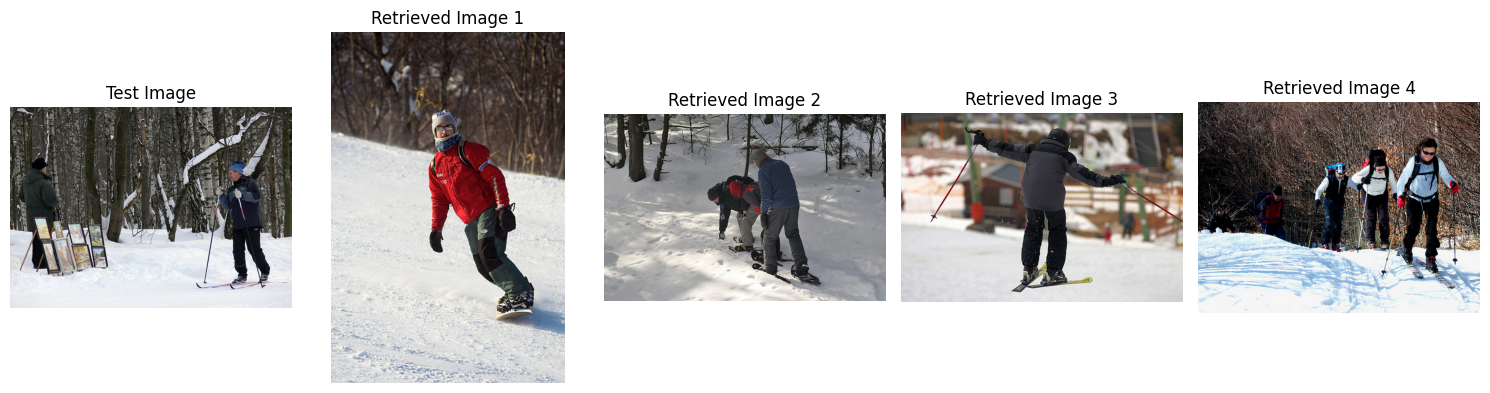

Distances: [[0.8687641  0.86808366 0.865948   0.85926753]]


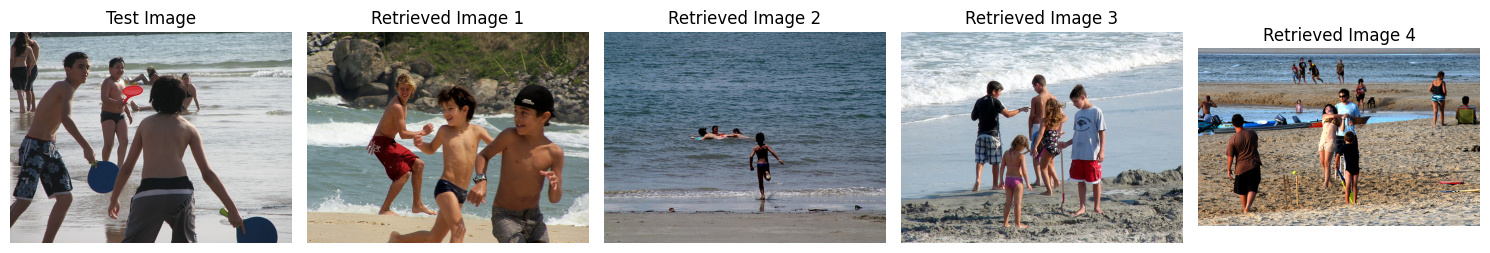

Distances: [[0.7396997  0.71631193 0.69675565 0.6931975 ]]


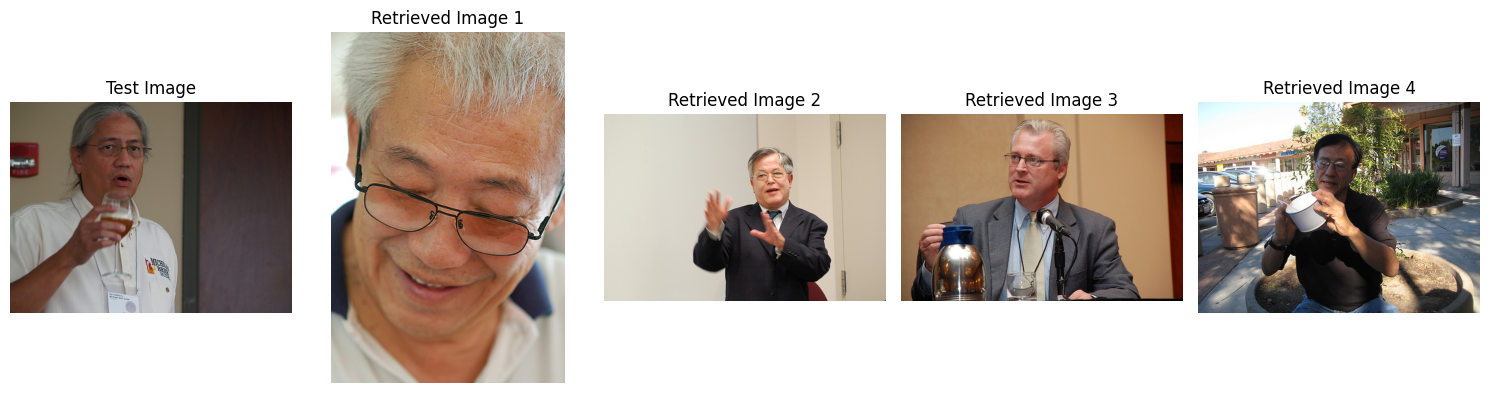

Distances: [[0.8332335  0.8181306  0.8133027  0.80614644]]


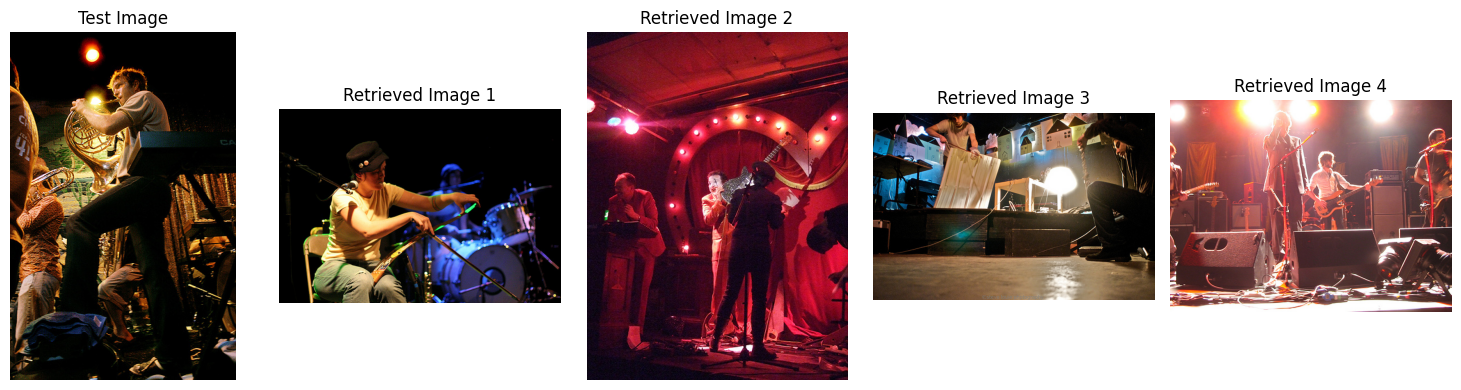

Distances: [[0.8253474  0.81506395 0.80988634 0.8062047 ]]


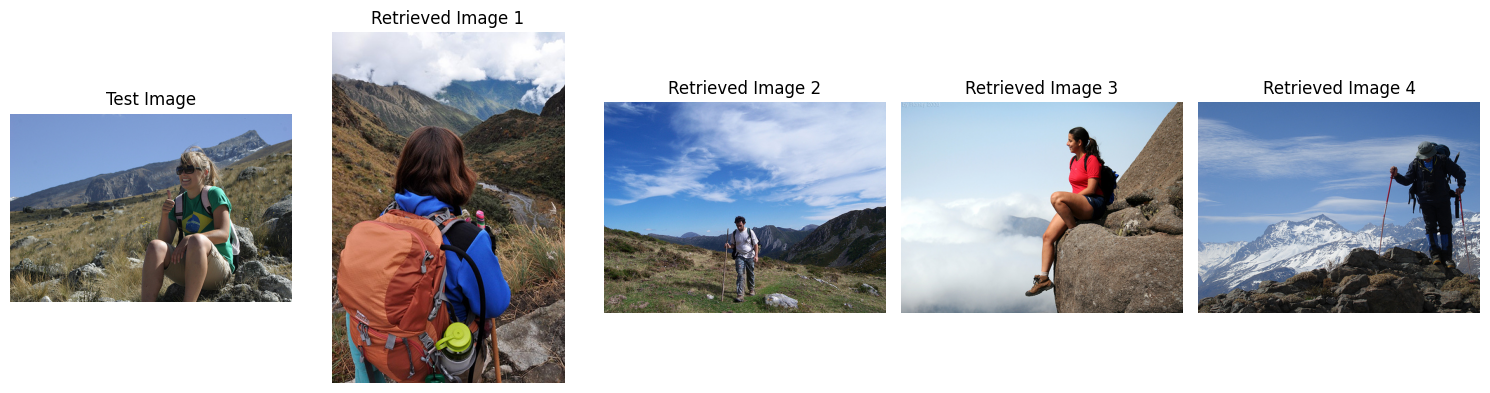

Distances: [[0.8845316 0.8765516 0.867643  0.8662566]]


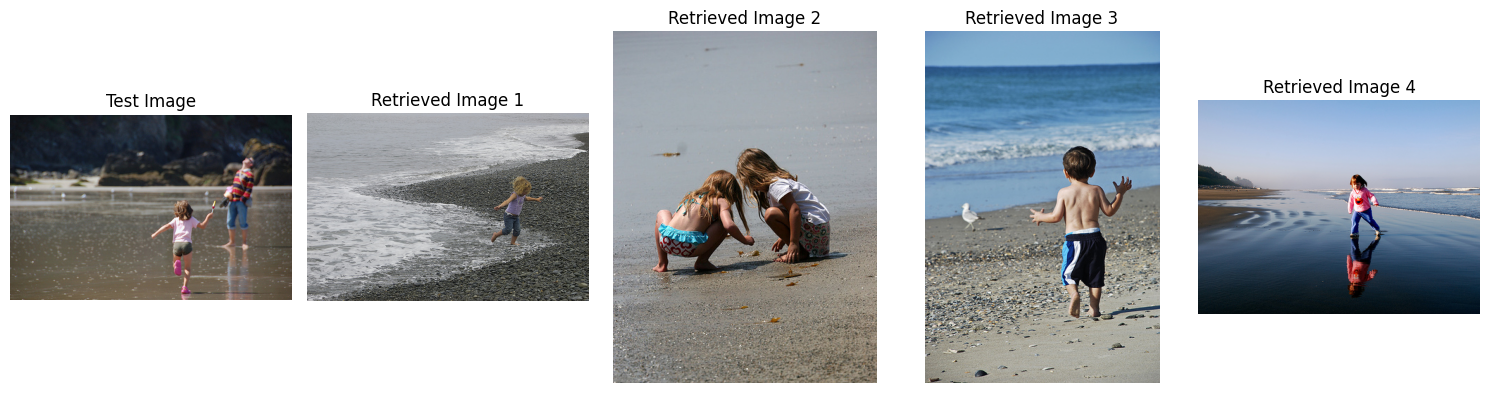

Distances: [[0.78875196 0.7817184  0.771569   0.77120143]]


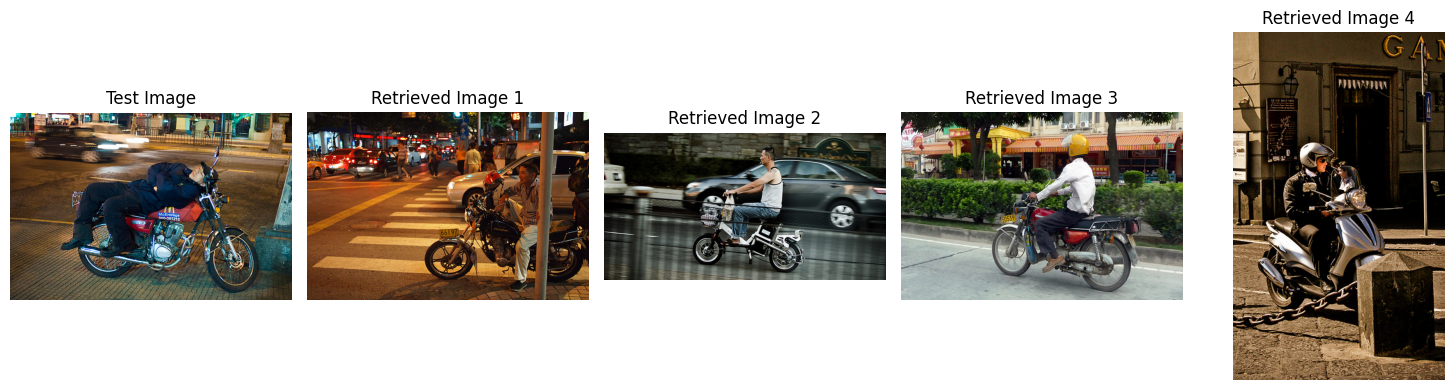

Distances: [[0.82501334 0.814183   0.8105726  0.8002978 ]]


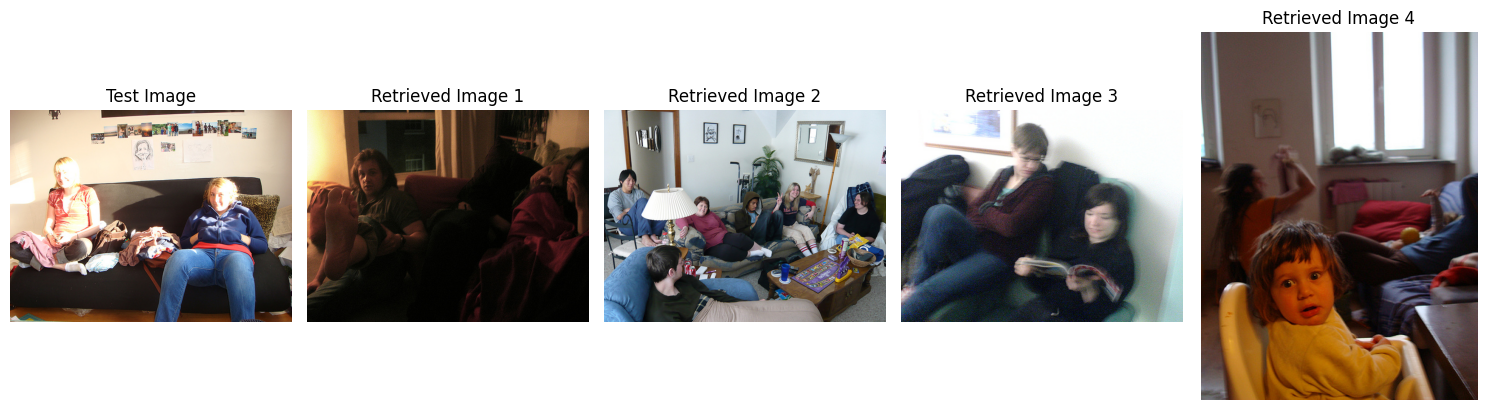

Distances: [[0.8369257  0.7587011  0.75236535 0.7409004 ]]


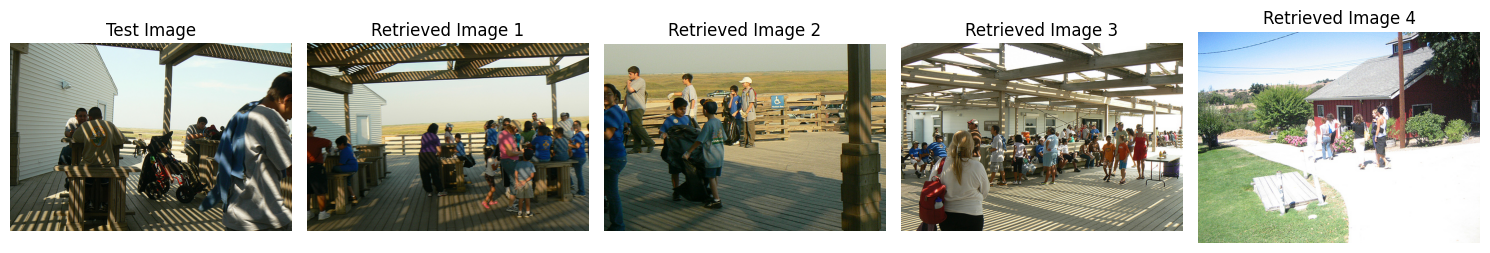

Distances: [[0.8557269  0.83764017 0.8309868  0.82226884]]


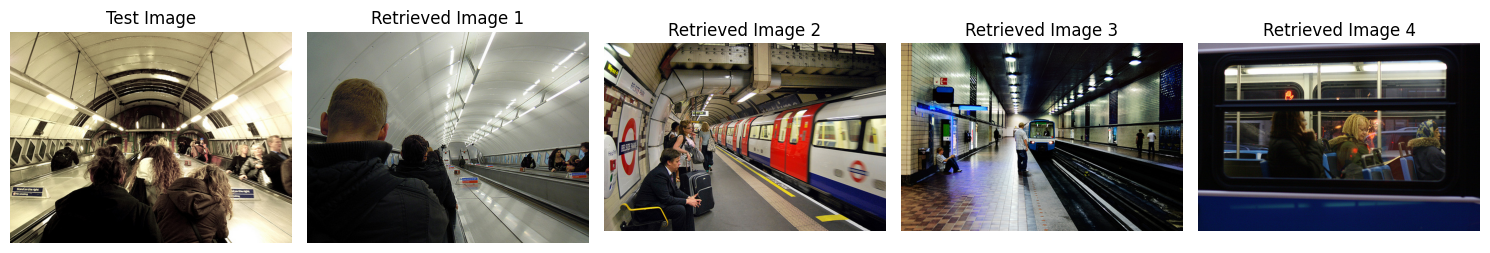

In [67]:
k = 4
sample_idx = [1, 25, 47, 112, 501, 390, 777, 909, 321, 910]
base_path = "dataset/flickr30k_images"

for i in range(len(sample_idx)):
    test_img_path = os.path.join(base_path, f'test/{test_dataset[sample_idx[i]]['image_name']}')
    
    retrieved_idx = retrieve_k_similar_images(test_dataset[sample_idx[i]], k)
    retrieved_img_paths = []
    for idx in retrieved_idx[0]:
        retrieved_img_paths.append(os.path.join(base_path, f'train/{metadata[str(idx)]['image_name']}'))
        
    display_images(test_img_path, retrieved_img_paths)

Sample Captions

In [77]:
retrieved_idx = retrieve_k_similar_images(test_dataset[sample_idx[9]], k)
print("Query image captions:")
print(*test_dataset[sample_idx[9]]['captions'], sep='\n')

print("\nRetrieved Image Captions:")
for idx in retrieved_idx[0]:
    print(metadata[str(idx)]['image_name'])
    print(*metadata[str(idx)]['captions'], sep='\n', end='\n\n')

Distances: [[0.8557269  0.83764017 0.8309868  0.82226884]]
Query image captions:
A group of people is traveling through a terminal with moving walkways .
Crowds of people are riding escalators up and down in a large tunnel .
People at a terminal are on an elevator packed with others .
A group of people stand on a moving sidewalk .
A group of people going up an escalator .

Retrieved Image Captions:
5922190538.jpg
Several people going down an escalator  with a few others going up the up escalator .
People are riding an escalator up and down a subway station tunnel .
All the shoppers are moving up and down the escalator .
People standing in line in a crowded area .
People are lined up in a terminal

4762011238.jpg
People waiting for a subway train : one man in a black suit sitting on bench and three women standing or walking .
A man in a suit and tie and a woman with luggage join others in waiting in the London Underground .
People wait on a mass transit platform while a train speeds by 

### Load FAISS index and JSON Metadata (for future runs)

In [ ]:
with open(JSON_OUT, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print(metadata["0"])  # keys: 'title', 'captions', etc.


{'image_name': '1000092795.jpg', 'captions': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young  White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .']}


In [ ]:
faiss_index2 = faiss.read_index(FAISS_OUT)
print(f"Number of vectors in index: {faiss_index2.ntotal}")

Number of vectors in index: 30783
